# SGD with Momentum

In this reading material, you will learn about the stochastic gradient descent with momentum for optimization.






## Prerequisites:
To start with Stochastic Gradient Descent, you must have knowledge about:
- Workflow of a simple ANN
- Fundamentals of derivatives
- Backpropagation and Gradient Descent in an ANN


## Learning Objectives:
- Recall the process of Gradient Descent and take a deeper dive into its stochastic variant.
- Visualize changes that could be done to the base algorithm in order to improve the optimization process.


## Review of Gradient Descent and Stochastic Gradient Descent Algorithm
## Gradient Descent
Optimisation in general case is an extremely difficult task. Gradient descent is an iterative machine learning optimisation algorithm to reduce the cost function. Since, in neural networks, we aim to train the model to have optimised weights for better predictions, we need Gradient Descent.

Types of Gradient Descent are:

- Batch Gradient Descent
- Stochastic Gradient Descent
- Mini batch Gradient Descent


## Batch Gradient Descent

Batch Gradient Descent goes over the entire data once before updating the parameters. If we have a million points in our training set, we have to make million computations before we can take one little step of gradient descent.


## Stochastic Gradient Descent
Note that the gradient descent algorithm goes over the entire data once before updating the parameters.There is no approximation.

But there is a flipside. Imagine you have a million points in your training dataset then to make a single update to the parameters, it takes you to compute million computations.

So, how can we make the situation better?

For this, Stochastic Gradient Descent commonly known as SGD comes to the rescue. The core idea of SGD is to skip taking all the datapoints and just randomly select one data point to calculate the gradients each time. Surely, as it takes only 1 datapoint rather than a million data points in a dataset while updating, it takes much less time to perform a single update compared to the Vanilla GD.


The general pseudocode of SGD can be written down as:

1. `Initialise the parameters with learning rate`
2. `For iteration`

    2.1 `Draw random sample with replacement`

    2.2 `Compute Prediction`

    2.3 `Compute Loss`

    2.4 `Compute Gradients`

    2.5 `Update Parameters`





<p>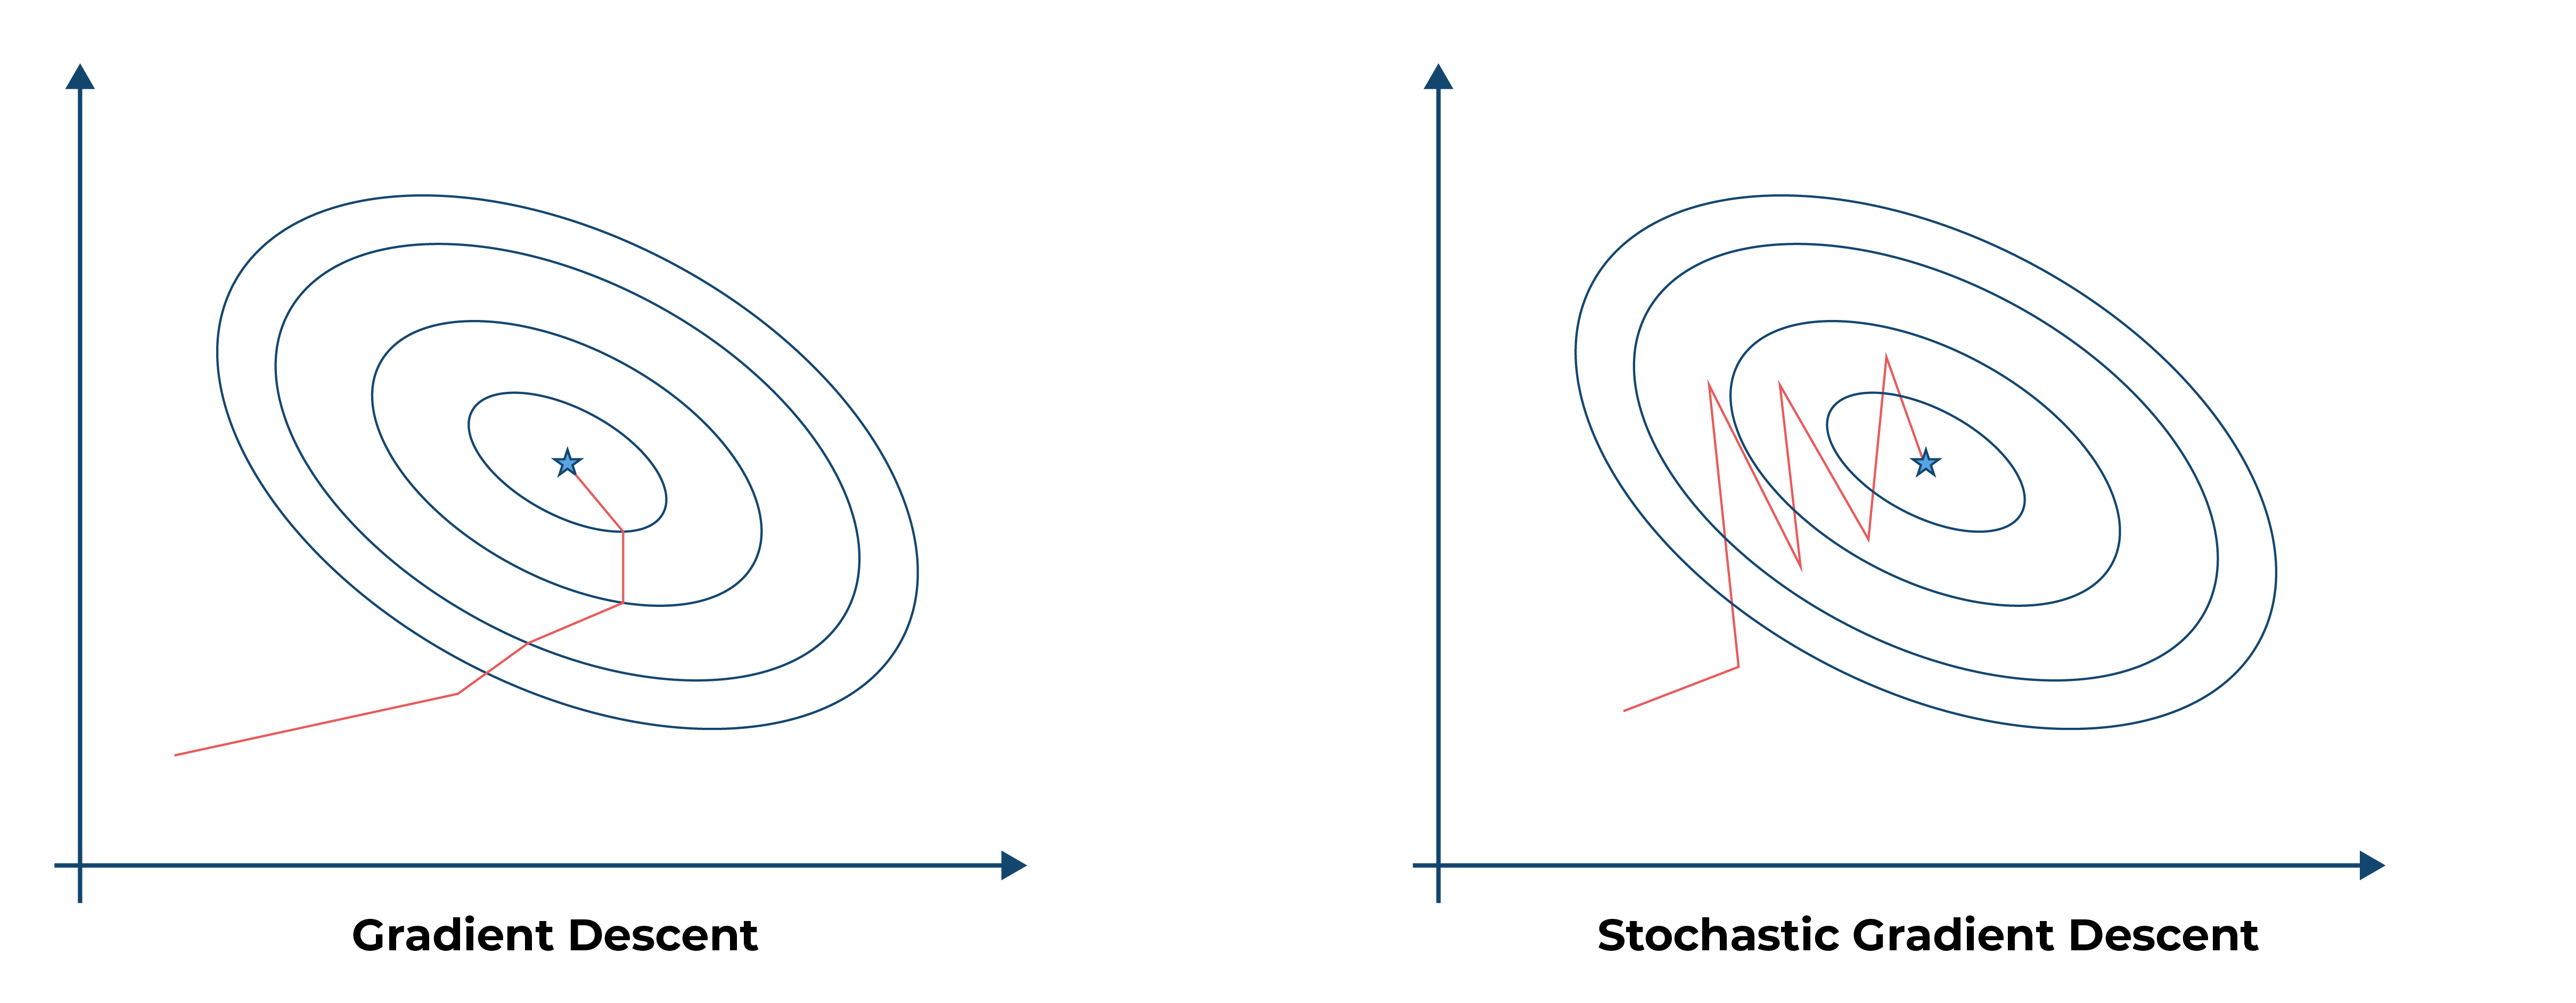</p>


## Challenges with SGD

Using SGD also comes with its own set of challenges. Having to calculate the derivative with only one random point can prove to be difficult in the long run as it would take a **longer time to converge to the optimal solution**. Moreover, as the points are selected randomly and updates happen frequently, there is a chance of **high variance** resulting in **heavy fluctuation** in the optimization path as shown in figure above.

Apart from time complexity and heavy fluctuation, we can also see that SGD uses a **constant learning rate throughout** which might not be the optimal approach in most of the cases. As much as finding the suitable learning rate is a challenge, we may also encounter situations where a constant learning rate leads to a **comparatively slower convergence.**

Another major concern comes with **datasets of higher dimensionality**. Adding to the challenge of escaping local minimas, such datasets also come with **saddle points**(points where one dimension slopes up and the other dimension slopes down). For SGD to escape such points is a challenge in itself.

There is a concept of **exponentially moving average** to overcome this problem.
Applying this concept with SGD is basically altogether called **SGD with momentum.**



# Momentum



<p>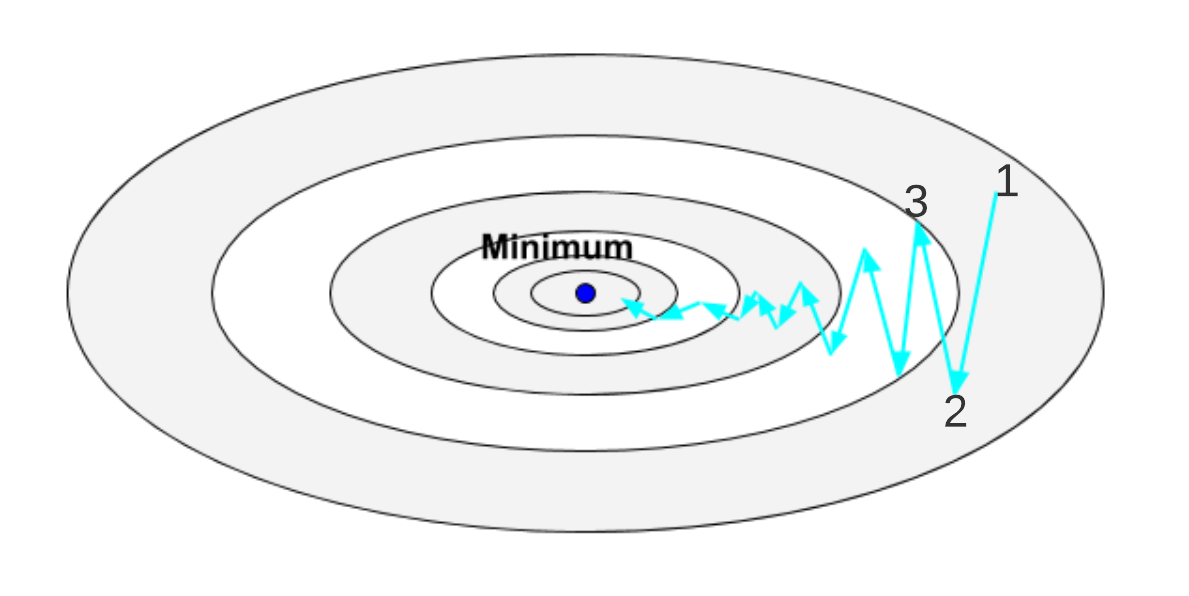</p>

Suppose our gradient descent algorithm starts from the right of the picture, numbered as 1. After one iteration of gradient descent, suppose you end up heading low towards 2. Now when we perform another iteration, it moves upward towards 3. After another iteration it moves down again.

As you can see, the algorithm is converging towards the minimum, but oscillating back and forth in the y-axis. We are also not able to choose a high learning rate because this will mean that the algorithm might overshoot, and diverge in the y-axis.

We want the model to move quicker in the direction of the x-axis than in the y-axis. This is the fundamental principle of of momentum.




## Exponentially weighted moving average
This is a mathematical technique used for many optimization algorithms. It smoothes over the vibration in the y-axis.



<p>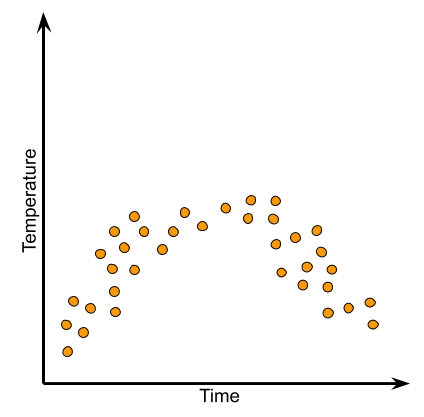</p>

Consider the noisy data above. As time ($t$) goes by, the readings for temperature ($\theta$) change. Even though there is a certain pattern in the data, when we actually measure the individual data points, the values will jump around a lot.

We apply the Exponentially weighted (moving) averages algorithm. The term "moving" is used in Statistical literature, but here we use the short form.

Let $t_1$ be the first temperature measurement. According to the Exponentially weighted average algorithm, we use a system to smooth out the measurements across time. Instead of observing $t_1$ directly, we pass it through a smoothing function and use the value $v_1$ instead.

$v_1 = 0.9 \times$(previous value) + $0.1 \times t_1$

Here, $v_1$ is the new value we will use. Since we don't have a previous measurement, we will use zero as our previous temperature. As the equation shows, we will only use 10% of the actual value of $t_1$. For the next value, the formula will be:

$v_2 = 0.9 \times v_1 + 0.1 \times t_2$, the next will be
$v_3 = 0.9 \times v_2 + 0.1 \times t_3$ and so on.

As you can see, the previous value of temperature is given a large weight, and the current value is given less weight. The real value of $t_1$ is not directly used. Doing this will create a "lag" in the curve, which will help smooth it out. If applied on the above data, it might output something like this:



<p>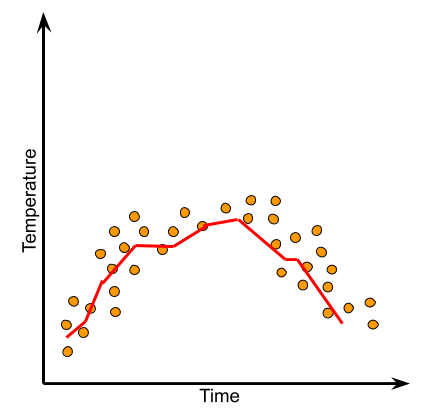</p>




This is the exponentially weighted moving average of the data. The general formula for it would be

$v_t = \beta \times v_{t-1} + (1- \beta)\times t_t$

$v_{t-1}$ is the previous value. $t_t$ is the current value of temperature. We have converted the $0.9$ into a hyperparameter $\beta$. The relevant $1-\beta$ replaces the $0.1$ so that $\beta$ and $(1-\beta)$ sum to 1. Bear in mind that we must choose a value for $\beta$ that is less than one.




##Why is it called exponential?

Let us observe three timesteps individually.
$$v1 = 0.9 \times v_0 + 0.1 \times t_1$$
$$v2 = 0.9 \times v_1 + 0.1 \times t_2$$
$$v3 = 0.9 \times v_2 + 0.1 \times t_3$$
Now, if we replace the value of $v_2$ in the third equation, we get
$$v3 = 0.1 \times t_3 + 0.9 \times v_2 $$
$$=0.1 \times t_3 +0.9 \times(0.1 \times t_2 + 0.9 \times v_1) $$
$$=0.1 \times t_3 +0.9 \times 0.1 \times t_2 + (0.9)^2 \times v_1) $$
Notice the power on top of $0.9$. If we expand $v_1$ as well, we get
$$v_3=0.1 \times t_3 +0.9 \times 0.1 \times t_2 + (0.9)^2 \times (0.1 \times t_1 + 0.9 \times v_0) $$
$$=0.1 \times t_3 +0.9 \times 0.1 \times t_2 + (0.9)^2 \times 0.1 \times t_1 + (0.9)^3 \times v_0 $$

The more time steps you add, the more the $\beta$ parameter (in this case 0.9) gets exponentiated.


##Behaviour
Bear in mind that the first term is $t_3$. Looking at this term, we are multiplying it by $0.1$. The next term is being multiplied by $0.9 \times 0.1$. The next term is being multiplied by $(0.9)^2 \times 0.1$ and so on.

So to calculate the $t^{th}$ term, we are averaging over a few preceding terms. This makes the function smoother.

The equation that gives how many time steps it averages over is given by:
$$\approx \frac{1}{1-\beta}$$

If we replace the value $0.9$ in this equation:

$$\approx \frac{1}{1-0.9}$$
$$\approx 10$$

If you wanted to average over 2 days:

$$\approx \frac{1}{1-0.5}$$
$$\approx 2$$

If you wanted to average over 50 days:

$$\approx \frac{1}{1-0.98}$$
$$\approx 50$$


## Applying Momentum to gradients

As you can imagine, instead of taking the gradients directy, we can take exponentially weighted averages of gradients to smooth out the unnecessary vibrations and converge faster.

Instead of updating the weights using the equation
$$W_{t+1} = W_{t}-(\alpha \times dW)$$
where $\alpha$ is the learning rate and $dW$ is the gradient, we can substitute it with:
$$W_{t+1} = W_{t}-(\alpha \times V_t)$$

where the current value $V_t$ is given by
$$V_t=\beta \times V_{t-1} + (1-\beta)dW_t$$

Here, $dW_t$ is the gradient at time $t$.

*Note:* A value of $0.9$ is common for $\beta$. This means that we usually average over the last 10 gradients. Also, we changed the way we updated the gradients here. But when implementing this, remember that we will do the same for the bias term as well.


## A brief look into Nesterov Momentum
Momentum based gradient descent is good at gentle regions, it moves very fast but it has a problem of oscillation.

Momentum based gradient descent moves according to the history and then a bit more according to the current gradient. It's sure that we are going to move at least by the history. So what if, we update partially updated weight as per the history and have a way to look ahead at that point?
How is it if we calculate the gradient at partially updated value?

That's what Nesterov momentum does.

Let's look mathematically.

$$\bigtriangledown w_{look ahead} = w_t - \gamma V_{t-1}$$
$$V_t = \gamma V_{t-1} + \eta \bigtriangledown w_{look ahead}$$
$$ w_{t+1} = w_{t}-V_t$$

This mathematical expressions can be depicted in the figure below.


<p>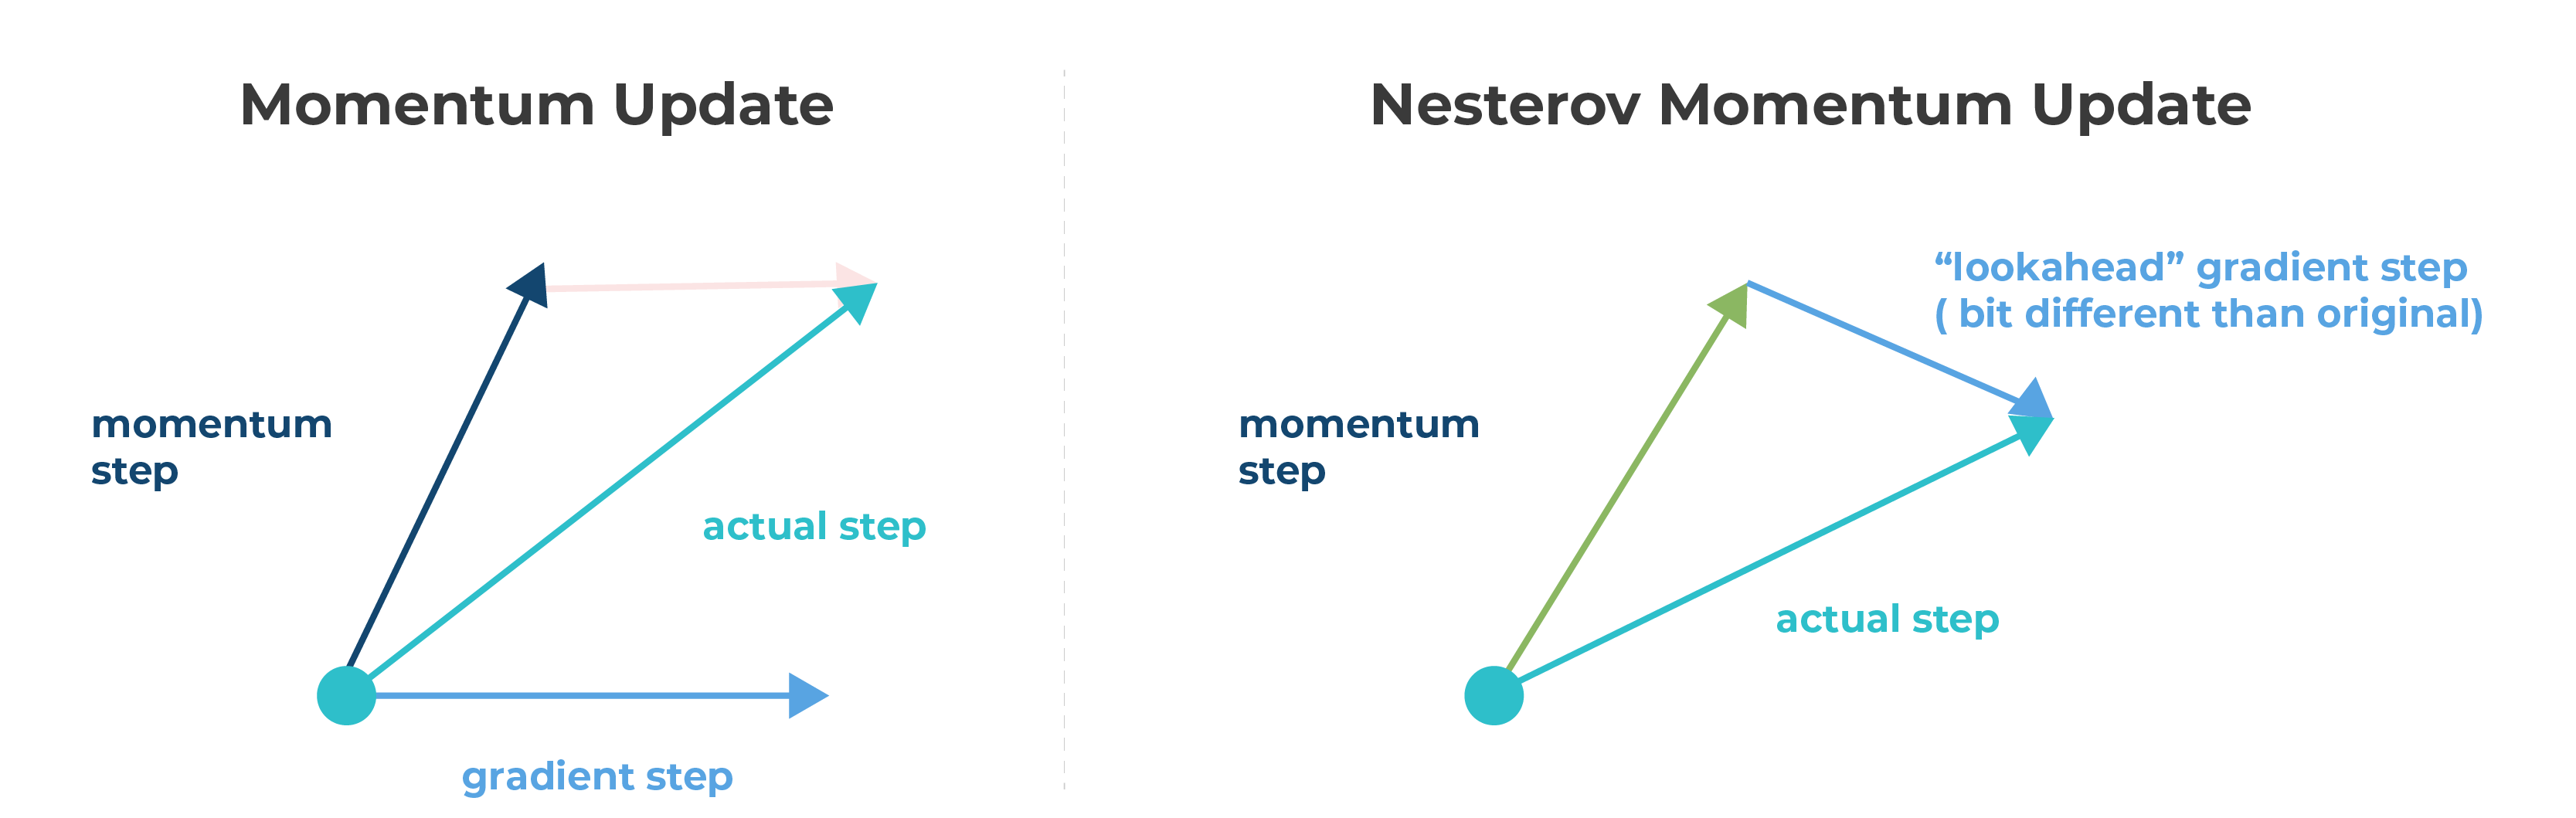</p>







Throughout this unit we will be using a polynimial curve to demostrate the effect of various optimisation algorithm. Expression and diagram of the curve is shown below:
$$ f(x) = x^4-9.5x^3+30.5x^2-37x+12 $$



<p>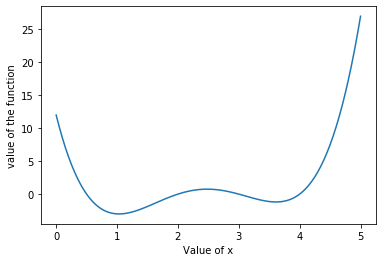</p>




Now, its the task of optimisation algorithm to find out the point where the function has a minimum value.




### Implementation of SGD without momentum using tensorflow


In [ ]:
def SGD(x):
  """
  Thus function implement Stochastic gradients descent.

  Parameters
  ---------
  x : point where the initialisation of optimisation algorithm

  Returns
  -------
  x : optimal value for x after saissying convergence criteria
  """
  t = tf.constant(0.0)
  while(1):
    t += 1
    g = grad_func(x)
    x_old = x
    x = x- learning_rate*(g)
    if (tf.reduce_mean(tf.math.abs(x-x_old))<1e-8): ## Convergence Criteria
      break
  return x

### Implementation of SGD without momentum using pytorch


In [ ]:
def SGD(x: torch.Tensor):
  """
  Thus function implement Stochastic gradients descent.

  Parameters
  ---------
  x : point where the initialisation of optimisation algorithm

  Returns
  -------
  x : optimal value for x after saissying convergence criteria
  """
  t = 0.0
  while(1):
    t += 1.0
    g = grad_func(x)
    x_old = x
    x =  x - learning_rate * g
    if torch.mean(torch.abs(x - x_old)) < 1e-8: ## Convergence Criteria
      break
  return x

Let's visualise in the following animation.






<p>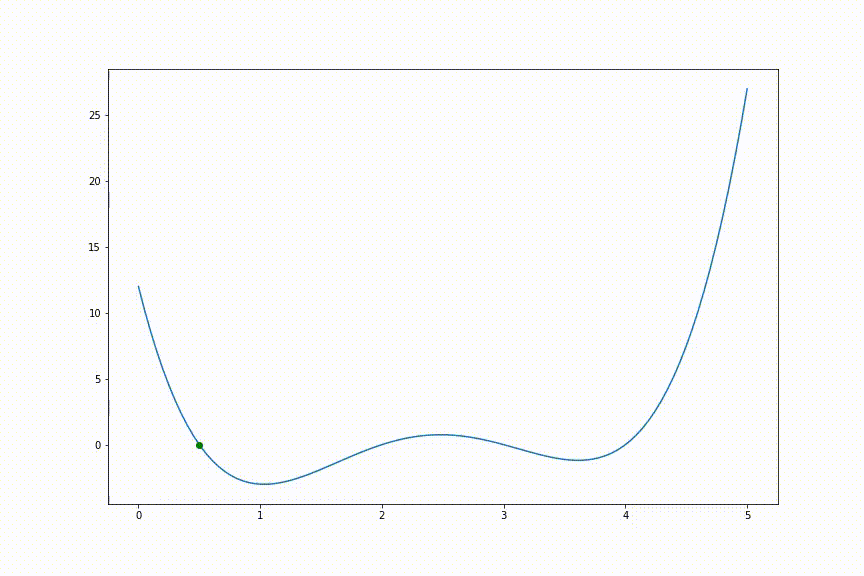</p>

Here, we see that the convergence is very random with lot's of noise embedded. Now, we will see how momentum resolves this issue.


To make the things more clear, here below is the result obtained from the above algorithm.


<p>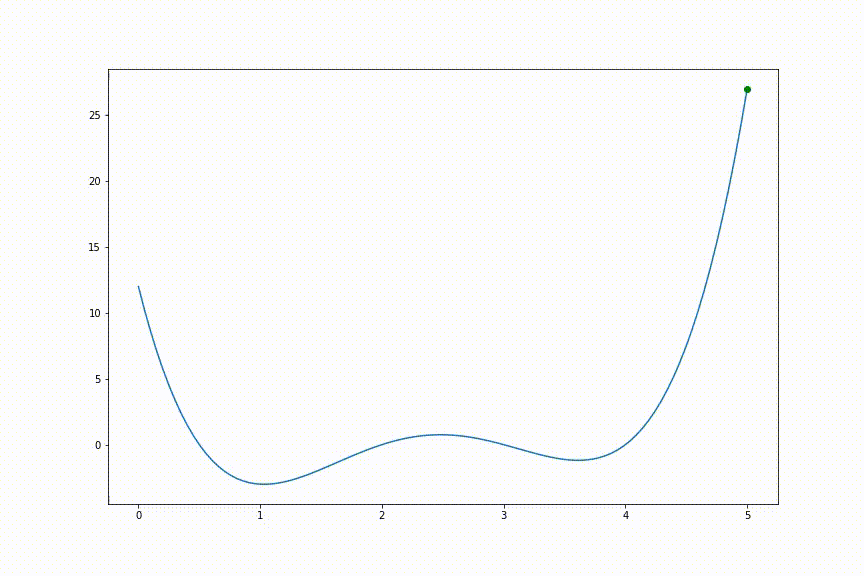</p>


From the above animation, we can draw out few things. The momentum component helps to track the previous steps and the convergence is not random and depends on the initialisation.But SGD with momentum leaves sometims a drawback of overshooting due to large momentum.


### Implementation of SGD with momentum using tensorflow



In [ ]:
# x is the initial point form where the optimisation begins.

def SGD_momentum(x):
  """
  This function implements SGD with momentum as per the algorithm.

  Parameters
  ----------
  x : point of initiation of the optimisation

  Returns
  -------
  x -- optimal value after the optimisation

  """
  t = tf.constant(0.0)
  velocity = tf.constant(0.0)

  while(1):
    t += 1
    x_old = x
    g = grad_func(x)
    velocity = gamma_1*velocity + (1-gamma_1)*g
    x = x - learning_rate*velocity
    if (tf.reduce_mean(tf.math.abs(x-x_old))<1e-8):
      break

  return x



### Implementation of SGD with momentum using pytorch



In [ ]:
# x is the initial point form where the optimisation begins.

def SGD_momentum(x: torch.Tensor):
  """
  This function implements SGD with momentum as per the algorithm.

  Parameters
  ----------
  x : point of initiation of the optimisation

  Returns
  -------
  x -- optimal value after the optimisation

  """
  t = 0.0
  velocity = 0.0

  while(1):
    t += 1
    x_old = x
    g = grad_func(x)
    velocity = gamma_1 * velocity + (1-gamma_1)*g
    x = x - learning_rate*velocity
    if torch.mean(torch.abs(x-x_old)) < 1e-8 :
      break

  return x

## Comparision between SGD and SGD with momentum




SGD has trouble navigating ravines. Ravine is an area, where the surface curves much more steeply in one dimension than in another which are common near local minimas. SGD will tend to oscillate across the narrow ravine since the negative gradient will point down one of the steep sides rather than along the ravine towards the optimum. Momentum helps accelerate gradients in the right direction.
<br><br>
<center>
<figure>


<p>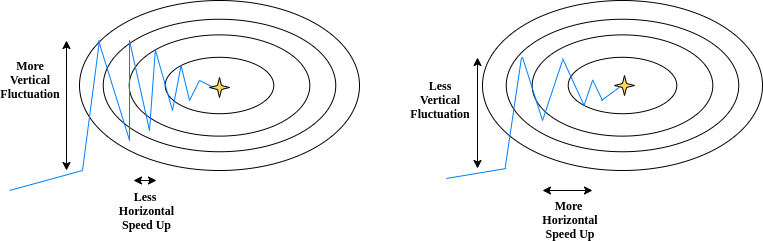</p>
<figcaption align="center">Figure : SGD vs SGD with momentum </figcaption>
</figure>
</center>

<br>

We can take the analogy of pushing down a ball in a hill as using momentum. The ball accumulates momentum as it rolls downhill, becoming faster and faster on the way. The same thing happens to our parameter updates: the momentum term increases for dimensions whose gradients point in the same directions and reduces updates for dimensions whose gradients change directions. As a result, we gain faster convergence and reduced oscillation in SGD with momentum.


## Key Takeaways:

1.  Stochastic Gradient Descent is a variant of Vanilla GD, where 1 random point is taken to calculate derivative for weight updates.
2. SGD also suffers from heavy fluctuation in the optimization path and convergence in saddle points in case of datasets with high dimensionality.
3. Modifications to the SGD Algorithm in terms of momentum concepts are practiced in SGD with Momentum.


## References

1. Bushaev V. (2017),Stochastic Gradient Descent with momentum. <br>
https://towardsdatascience.com/stochastic-gradient-descent-with-momentum-a84097641a5d

2. Ruder S. (2017), An overview of gradient descent optimization
algorithms. <br>
https://arxiv.org/abs/1609.04747


3. [Importance of momentum in DL](https://www.cs.toronto.edu/~fritz/absps/momentum.pdf)

4. [Intro to optimization](https://blog.paperspace.com/intro-to-optimization-momentum-rmsprop-adam/)




## Aditional Resources


1.   Sra S.(2018),Stochastic Gradient Descent,MIT Open Courseware.(https://www.youtube.com/watch?v=k3AiUhwHQ28)


